# Fly connectome directed modularity baselines
This notebook uses the same fly connectome data and preprocessing as the bimodularity notebook, but replaces bimodularity with two directed NetworkX baselines (Louvain and greedy modularity). It summarizes communities and produces comparable plots.


In [1]:
import sys
print("Notebook python:", sys.executable)

# If you need deps in a fresh environment:
# !{sys.executable} -m pip install -r ../requirements.txt


Notebook python: /home/klrshak/miniconda3/envs/bimodularity/bin/python


In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path
from sklearn.metrics import adjusted_mutual_info_score

random.seed(0)
np.random.seed(0)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlepad"] = 12
plt.style.use("seaborn-v0_8-whitegrid")


In [3]:
# Data paths (match bimodularity notebook layout)
DATA_DIR = Path("../data")
CONNECTIONS_PATH = DATA_DIR / "connections_princeton.csv"
ANNOTATIONS_PATH = DATA_DIR / "classification.csv"

EDGE_WEIGHT_COL = "syn_count"
MIN_SYN = 10
MAX_NODES = 1000
RANDOM_STATE = 0

# Fallback to locate repo root if needed
_CWD = Path.cwd().resolve()
if not DATA_DIR.exists():
    if (_CWD / "data").exists():
        DATA_DIR = _CWD / "data"
    elif (_CWD.parent / "data").exists():
        DATA_DIR = _CWD.parent / "data"

CONNECTIONS_PATH = DATA_DIR / "connections_princeton.csv"
ANNOTATIONS_PATH = DATA_DIR / "classification.csv"

if not CONNECTIONS_PATH.exists():
    alt = DATA_DIR / "raw" / "connections_princeton.csv"
    if alt.exists():
        CONNECTIONS_PATH = alt
    else:
        raise FileNotFoundError(f"Missing {CONNECTIONS_PATH}")

if not ANNOTATIONS_PATH.exists():
    raise FileNotFoundError(f"Missing {ANNOTATIONS_PATH}")

print("Connections:", CONNECTIONS_PATH)
print("Annotations:", ANNOTATIONS_PATH)


Connections: ../data/raw/connections_princeton.csv
Annotations: ../data/classification.csv


In [4]:
connections = pd.read_csv(CONNECTIONS_PATH)
connections = connections[["pre_root_id", "post_root_id", EDGE_WEIGHT_COL]].copy()
connections.head()


,pre_root_id,post_root_id,syn_count
0,720575940625363947,720575940623224444,12
1,720575940630432382,720575940618518557,67
2,720575940627314521,720575940626337738,10
3,720575940620280405,720575940620204726,15
4,720575940636942447,720575940613789411,1


In [5]:
ann = pd.read_csv(ANNOTATIONS_PATH)
ann.columns = [c.strip() for c in ann.columns]
print("Annotation columns:", ann.columns.tolist())

if "class" not in ann.columns:
    raise ValueError("Expected a 'class' column in classification.csv")


Annotation columns: ['root_id', 'flow', 'super_class', 'class', 'sub_class', 'hemilineage', 'side', 'nerve']


## Preprocess graph (ROI filter, reindex, adjacency, DiGraph)


In [6]:
TYPE_ORDER = ["PN", "KC", "MBON", "Other"]

def build_graph_and_mappings(connections, ann, edge_weight_col="syn_count", min_syn=10, max_nodes=1000):
    label_series = ann["class"].fillna("").astype(str)
    label_upper = label_series.str.upper()

    pns = set(ann.loc[label_upper.isin(["ALPN", "TPN"]), "root_id"].astype(int))
    kcs = set(ann.loc[label_upper == "KENYON_CELL", "root_id"].astype(int))
    mbons = set(ann.loc[label_upper == "MBON", "root_id"].astype(int))
    roi_nodes = pns | kcs | mbons

    connections_roi = connections[
        connections["pre_root_id"].isin(roi_nodes)
        & connections["post_root_id"].isin(roi_nodes)
    ].copy()

    stats = {
        "pn": len(pns),
        "kc": len(kcs),
        "mbon": len(mbons),
        "roi_nodes": len(roi_nodes),
        "edges_roi": len(connections_roi),
    }

    if min_syn is not None:
        connections_roi = connections_roi[connections_roi[edge_weight_col] >= min_syn].copy()

    stats["edges_after_min_syn"] = len(connections_roi)

    out_strength = connections_roi.groupby("pre_root_id")[edge_weight_col].sum()
    in_strength = connections_roi.groupby("post_root_id")[edge_weight_col].sum()
    strength = out_strength.add(in_strength, fill_value=0)

    if max_nodes is not None and len(strength) > max_nodes:
        keep_nodes = strength.sort_values(ascending=False).head(max_nodes).index
    else:
        keep_nodes = strength.index

    connections_roi = connections_roi[
        connections_roi["pre_root_id"].isin(keep_nodes)
        & connections_roi["post_root_id"].isin(keep_nodes)
    ].copy()

    stats["final_nodes"] = len(keep_nodes)
    stats["final_edges"] = len(connections_roi)

    node_list = pd.Index(sorted(keep_nodes))
    node_to_idx = {n: i for i, n in enumerate(node_list)}
    connections_roi["pre_idx"] = connections_roi["pre_root_id"].map(node_to_idx).astype(int)
    connections_roi["post_idx"] = connections_roi["post_root_id"].map(node_to_idx).astype(int)

    edges_grouped = (
        connections_roi.groupby(["pre_idx", "post_idx"], as_index=False)[edge_weight_col]
        .sum()
        .rename(columns={edge_weight_col: edge_weight_col})
    )

    n = len(node_list)
    adj = np.zeros((n, n), dtype=float)
    for row in edges_grouped.itertuples(index=False):
        adj[int(row.pre_idx), int(row.post_idx)] = float(getattr(row, edge_weight_col))

    G = nx.DiGraph()
    G.add_nodes_from(range(n))
    for row in edges_grouped.itertuples(index=False):
        G.add_edge(
            int(row.pre_idx),
            int(row.post_idx),
            **{edge_weight_col: float(getattr(row, edge_weight_col))},
        )

    return connections_roi, edges_grouped, node_list, node_to_idx, adj, G, pns, kcs, mbons, roi_nodes, stats

def compute_node_labels(node_list, pns, kcs, mbons):
    root_ids = np.array(node_list, dtype=int)
    labels = np.array(["Other"] * len(root_ids), dtype=object)
    labels[np.isin(root_ids, list(pns))] = "PN"
    labels[np.isin(root_ids, list(kcs))] = "KC"
    labels[np.isin(root_ids, list(mbons))] = "MBON"
    return labels

def sort_communities(communities):
    return sorted(communities, key=lambda c: (-len(c), min(c) if len(c) else -1))

def run_louvain(G, weight_col, seed=0):
    communities = nx.community.louvain_communities(G, weight=weight_col, seed=seed)
    return sort_communities(communities)

def run_greedy(G, weight_col):
    communities = nx.community.greedy_modularity_communities(G, weight=weight_col)
    return sort_communities(communities)

def community_assignments(communities, n_nodes):
    node_comm = np.full(n_nodes, -1, dtype=int)
    for cid, nodes in enumerate(communities):
        for n in nodes:
            node_comm[int(n)] = cid
    return node_comm

def modularity_matrix(A):
    kout = A.sum(axis=1, keepdims=True)
    kin = A.sum(axis=0, keepdims=True)
    m = A.sum()
    if m == 0:
        return np.zeros_like(A)
    return A - (kout @ kin) / m

def community_flow_matrix(edges_df, node_comm, n_comms, weight_col):
    F = np.zeros((n_comms, n_comms), dtype=float)
    for row in edges_df.itertuples(index=False):
        a = node_comm[int(row.pre_idx)]
        b = node_comm[int(row.post_idx)]
        if a >= 0 and b >= 0:
            F[a, b] += float(getattr(row, weight_col))
    return F

def summarize_communities(communities, labels, modularity_score, type_order=None):
    if type_order is None:
        type_order = TYPE_ORDER

    rows = []
    for cid, nodes in enumerate(communities):
        nodes = list(nodes)
        node_types = labels[nodes]
        counts = pd.Series(node_types).value_counts()
        total = len(nodes)
        mix = {
            t: round(100 * counts.get(t, 0) / total, 1) if total > 0 else 0.0
            for t in type_order
        }

        if total > 0:
            dominant_type = max(mix, key=mix.get)
            dominant_pct = mix[dominant_type]
        else:
            dominant_type = "Other"
            dominant_pct = 0.0

        rows.append(
            {
                "community_id": cid,
                "size": total,
                "dominant_node_type": dominant_type,
                "dominant_pct": dominant_pct,
                "node_type_mix": mix,
                "modularity_score": modularity_score,
            }
        )

    return pd.DataFrame(rows)

def make_community_labels(summary_df):
    labels = []
    for row in summary_df.itertuples(index=False):
        labels.append(
            f"C{row.community_id} ({row.dominant_node_type} {row.dominant_pct:.0f}%)"
        )
    return labels


In [7]:
def plot_community_sizes(summary_df, title):
    sizes = summary_df["size"].to_numpy()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(np.arange(len(sizes)), sizes, color="tab:blue")
    ax.set_title(title)
    ax.set_xlabel("community id (sorted by size)")
    ax.set_ylabel("size")
    plt.tight_layout()
    plt.show()

def plot_type_composition(summary_df, type_order, title):
    comp = np.vstack(
        [
            [row["node_type_mix"].get(t, 0.0) for t in type_order]
            for _, row in summary_df.iterrows()
        ]
    )
    fig, ax = plt.subplots(figsize=(8, 4))
    im = ax.imshow(comp, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(type_order)))
    ax.set_xticklabels(type_order)
    ax.set_yticks(range(len(summary_df)))
    ax.set_yticklabels([f"C{cid}" for cid in summary_df["community_id"]])
    ax.set_xlabel("node type")
    ax.set_ylabel("community")
    ax.set_title(title)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("percent of nodes")
    plt.tight_layout()
    plt.show()

def plot_flow_matrix(F, comm_labels, title):
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(F, cmap="magma")
    ax.set_xticks(range(len(comm_labels)))
    ax.set_xticklabels(comm_labels, rotation=45, ha="right")
    ax.set_yticks(range(len(comm_labels)))
    ax.set_yticklabels(comm_labels)
    ax.set_xlabel("receiver community")
    ax.set_ylabel("sender community")
    ax.set_title(title)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("synapse weight")
    plt.tight_layout()
    plt.show()

def plot_adjacency_blocks(adj, communities, title):
    order = []
    bounds = []
    total = 0
    for nodes in communities:
        nodes = sorted(nodes)
        order.extend(nodes)
        total += len(nodes)
        bounds.append(total)

    order = np.array(order, dtype=int)
    adj_ord = adj[np.ix_(order, order)]

    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(adj_ord, cmap="Greys", interpolation="nearest")
    for b in bounds[:-1]:
        ax.axhline(b - 0.5, color="red", linewidth=0.6)
        ax.axvline(b - 0.5, color="red", linewidth=0.6)

    ax.set_title(title)
    ax.set_xlabel("nodes (reordered)")
    ax.set_ylabel("nodes (reordered)")
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("synapse weight")
    plt.tight_layout()
    plt.show()

def plot_embedding_by_type(U, V, labels, title):
    u1 = U[:, 0]
    v1 = V[:, 0]
    type_colors = {"PN": "tab:blue", "KC": "tab:orange", "MBON": "tab:green", "Other": "tab:gray"}

    fig, ax = plt.subplots(figsize=(7, 6))
    for t in TYPE_ORDER:
        mask = labels == t
        if mask.sum() == 0:
            continue
        ax.scatter(
            u1[mask],
            v1[mask],
            s=12,
            alpha=0.7,
            label=f"{t} (n={mask.sum()})",
            color=type_colors[t],
        )

    ax.set_xlabel("u1 (sending coordinate)")
    ax.set_ylabel("v1 (receiving coordinate)")
    ax.set_title(title)
    ax.legend(frameon=True)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

def plot_embedding_by_comm(U, V, node_comm, title):
    u1 = U[:, 0]
    v1 = V[:, 0]

    fig, ax = plt.subplots(figsize=(7, 6))
    sc = ax.scatter(u1, v1, c=node_comm, s=12, alpha=0.8, cmap="tab20")
    ax.set_xlabel("u1 (sending coordinate)")
    ax.set_ylabel("v1 (receiving coordinate)")
    ax.set_title(title)
    ax.grid(True, alpha=0.2)
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("community id")
    plt.tight_layout()
    plt.show()


def select_top_communities(summary_df, top_k=6):
    return (
        summary_df.sort_values("size", ascending=False)
        .head(top_k)["community_id"]
        .astype(int)
        .tolist()
    )


def community_send_receive_mix(edges_df, node_comm, labels, weight_col, type_order=None):
    if type_order is None:
        type_order = TYPE_ORDER

    df = edges_df.copy()
    df["pre_comm"] = node_comm[df["pre_idx"].to_numpy(int)]
    df["post_comm"] = node_comm[df["post_idx"].to_numpy(int)]
    df["pre_type"] = labels[df["pre_idx"].to_numpy(int)]
    df["post_type"] = labels[df["post_idx"].to_numpy(int)]

    send = df.groupby(["pre_comm", "pre_type"])[weight_col].sum().unstack(fill_value=0)
    recv = df.groupby(["post_comm", "post_type"])[weight_col].sum().unstack(fill_value=0)

    for t in type_order:
        if t not in send.columns:
            send[t] = 0.0
        if t not in recv.columns:
            recv[t] = 0.0

    send = send[type_order]
    recv = recv[type_order]

    n_comms = int(node_comm.max()) + 1
    idx = pd.Index(range(n_comms), name="community")

    send = send.reindex(idx, fill_value=0)
    recv = recv.reindex(idx, fill_value=0)

    send_total = send.sum(axis=1).replace(0, np.nan)
    recv_total = recv.sum(axis=1).replace(0, np.nan)

    send_pct = (send.div(send_total, axis=0).fillna(0) * 100).round(1)
    recv_pct = (recv.div(recv_total, axis=0).fillna(0) * 100).round(1)

    return send_pct, recv_pct


def plot_send_receive_pies(send_pct, recv_pct, comm_ids, type_order, title):
    type_colors = {
        "PN": "#E41A1C",
        "KC": "#377EB8",
        "MBON": "#4DAF4A",
        "Other": "#999999",
    }

    n = len(comm_ids)
    fig, axes = plt.subplots(2, n, figsize=(3.4 * n, 6), subplot_kw={"aspect": "equal"})
    if n == 1:
        axes = np.array([[axes[0]], [axes[1]]])

    for col, cid in enumerate(comm_ids):
        send_vals = send_pct.loc[cid, type_order].to_numpy()
        recv_vals = recv_pct.loc[cid, type_order].to_numpy()

        send_labels = [t for t, v in zip(type_order, send_vals) if v > 0]
        recv_labels = [t for t, v in zip(type_order, recv_vals) if v > 0]

        send_colors = [type_colors[t] for t in send_labels]
        recv_colors = [type_colors[t] for t in recv_labels]

        send_values = [v for v in send_vals if v > 0]
        recv_values = [v for v in recv_vals if v > 0]

        ax_send = axes[0, col]
        ax_recv = axes[1, col]

        if sum(send_values) == 0:
            ax_send.text(0.5, 0.5, "No sending", ha="center", va="center", fontsize=10)
        else:
            ax_send.pie(
                send_values,
                labels=send_labels,
                colors=send_colors,
                startangle=90,
                textprops={"fontsize": 10},
            )

        if sum(recv_values) == 0:
            ax_recv.text(0.5, 0.5, "No receiving", ha="center", va="center", fontsize=10)
        else:
            ax_recv.pie(
                recv_values,
                labels=recv_labels,
                colors=recv_colors,
                startangle=90,
                textprops={"fontsize": 10},
            )

        ax_send.set_title(f"C{cid}")

    axes[0, 0].set_ylabel("Sending")
    axes[1, 0].set_ylabel("Receiving")

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


In [8]:
connections_roi, edges_grouped, node_list, node_to_idx, adj, G, pns, kcs, mbons, roi_nodes, stats = (
    build_graph_and_mappings(
        connections,
        ann,
        edge_weight_col=EDGE_WEIGHT_COL,
        min_syn=MIN_SYN,
        max_nodes=MAX_NODES,
    )
)

print(f"PN: {stats['pn']}, KC: {stats['kc']}, MBON: {stats['mbon']}")
print(f"ROI nodes (before pruning): {stats['roi_nodes']}")
print("Edges in ROI (before pruning):", stats['edges_roi'])
print("Edges after synapse threshold:", stats['edges_after_min_syn'])
print("Final nodes:", stats['final_nodes'])
print("Final edges:", stats['final_edges'])

keep_set = set(node_list)
print("Kept PN:", len(keep_set & pns))
print("Kept KC:", len(keep_set & kcs))
print("Kept MBON:", len(keep_set & mbons))

print(
    f"Nodes kept: {len(node_list)}, edges kept: {len(connections_roi):,}, total synapses: {edges_grouped[EDGE_WEIGHT_COL].sum():,}"
)


PN: 687, KC: 5177, MBON: 96
ROI nodes (before pruning): 5960
Edges in ROI (before pruning): 143943
Edges after synapse threshold: 24583
Final nodes: 1000
Final edges: 5951
Kept PN: 364
Kept KC: 576
Kept MBON: 60
Nodes kept: 1000, edges kept: 5,951, total synapses: 147,580


In [9]:
labels = compute_node_labels(node_list, pns, kcs, mbons)
print(pd.Series(labels).value_counts())


KC      576
PN      364
MBON     60
Name: count, dtype: int64


In [10]:
louvain_communities = run_louvain(G, EDGE_WEIGHT_COL, seed=RANDOM_STATE)
greedy_communities = run_greedy(G, EDGE_WEIGHT_COL)

node_comm_louvain = community_assignments(louvain_communities, len(node_list))
node_comm_greedy = community_assignments(greedy_communities, len(node_list))

assert (node_comm_louvain >= 0).all()
assert (node_comm_greedy >= 0).all()


In [11]:
louvain_modularity = nx.community.modularity(G, louvain_communities, weight=EDGE_WEIGHT_COL)
greedy_modularity = nx.community.modularity(G, greedy_communities, weight=EDGE_WEIGHT_COL)

louvain_summary = summarize_communities(louvain_communities, labels, louvain_modularity)
greedy_summary = summarize_communities(greedy_communities, labels, greedy_modularity)

print(f"Louvain communities: {len(louvain_communities)} | modularity: {louvain_modularity:.4f}")
print(louvain_summary.to_string(index=False))

print("")
print(f"Greedy communities: {len(greedy_communities)} | modularity: {greedy_modularity:.4f}")
print(greedy_summary.to_string(index=False))


Louvain communities: 8 | modularity: 0.5621
 community_id  size dominant_node_type  dominant_pct                                       node_type_mix  modularity_score
            0   500                 KC          77.0 {'PN': 22.6, 'KC': 77.0, 'MBON': 0.4, 'Other': 0.0}          0.562105
            1   262                 KC          53.4 {'PN': 45.8, 'KC': 53.4, 'MBON': 0.8, 'Other': 0.0}          0.562105
            2   137                 PN          79.6 {'PN': 79.6, 'KC': 20.4, 'MBON': 0.0, 'Other': 0.0}          0.562105
            3    48               MBON          83.3 {'PN': 0.0, 'KC': 16.7, 'MBON': 83.3, 'Other': 0.0}          0.562105
            4    22                 PN          63.6 {'PN': 63.6, 'KC': 36.4, 'MBON': 0.0, 'Other': 0.0}          0.562105
            5    21               MBON          71.4 {'PN': 0.0, 'KC': 28.6, 'MBON': 71.4, 'Other': 0.0}          0.562105
            6     9                 PN          88.9 {'PN': 88.9, 'KC': 11.1, 'MBON': 0.0, 'Oth

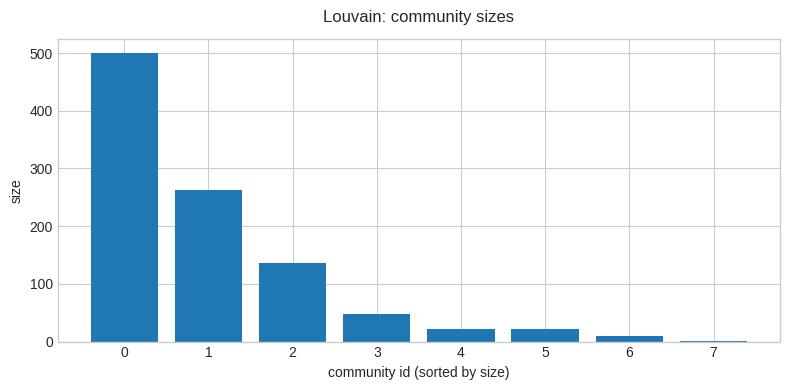

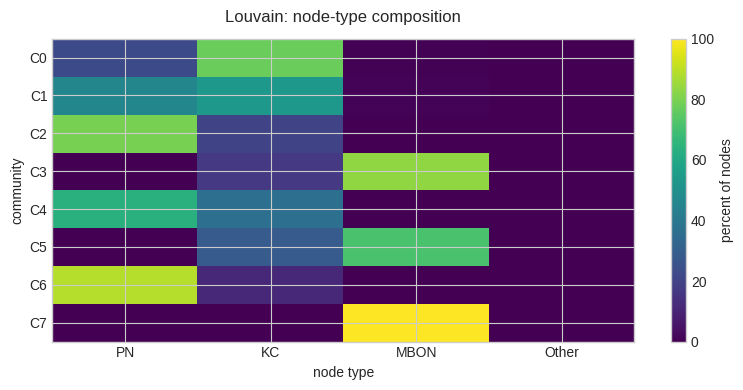

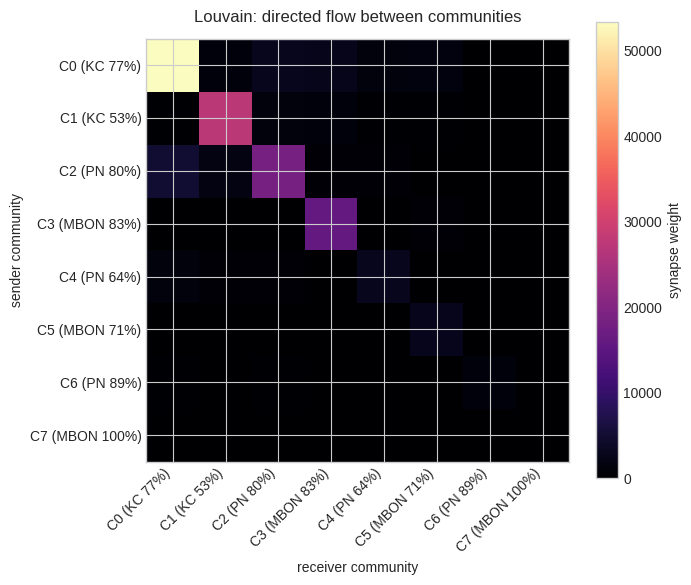

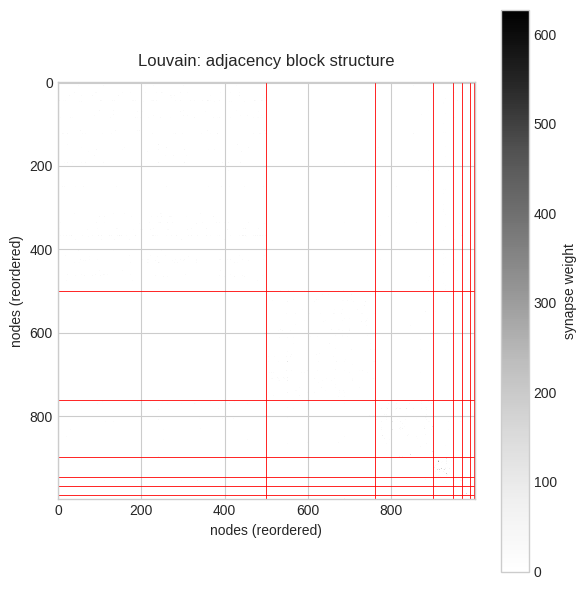

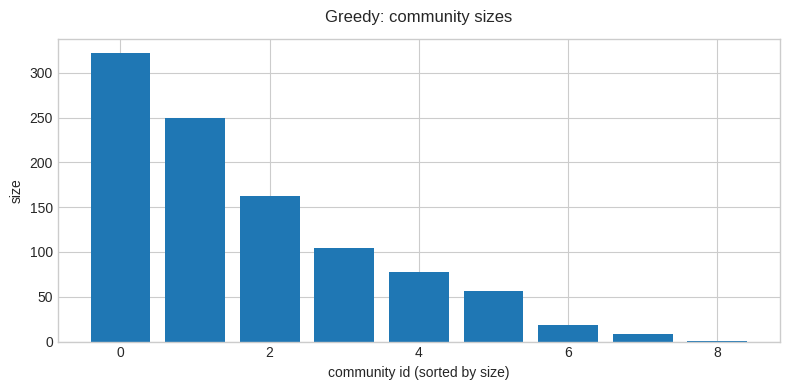

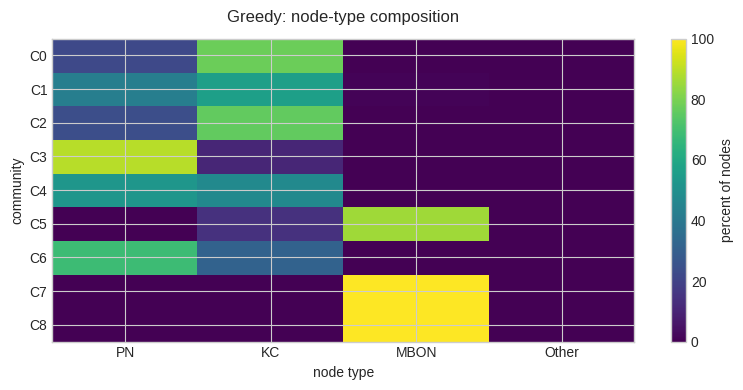

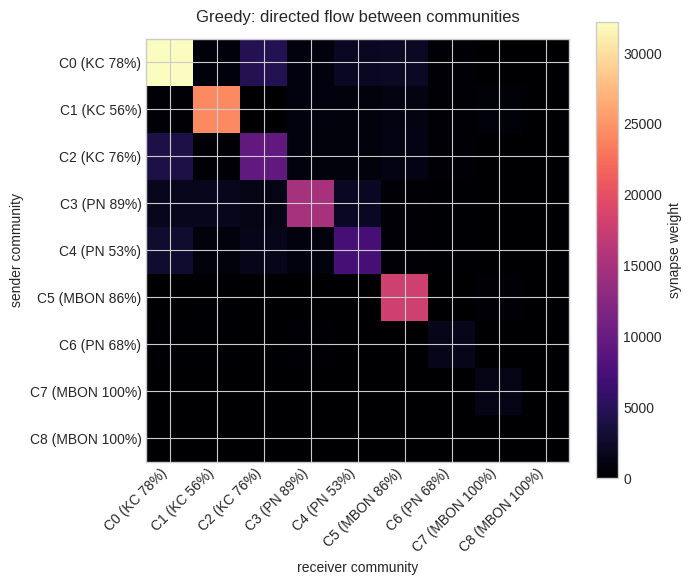

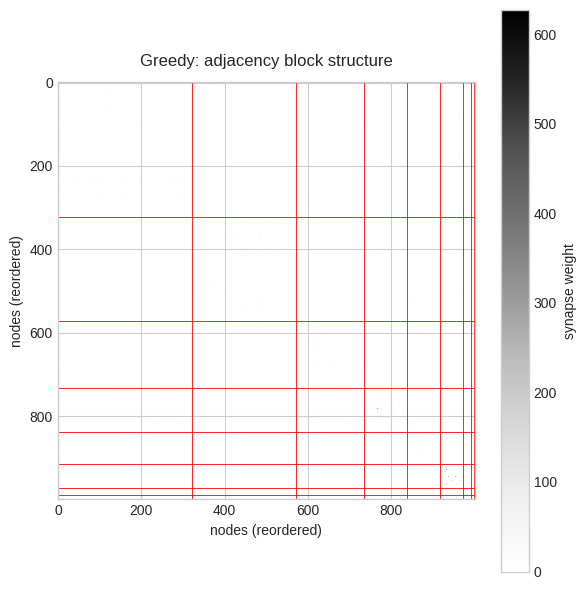

In [12]:
method_info = {
    "Louvain": {
        "communities": louvain_communities,
        "node_comm": node_comm_louvain,
        "summary": louvain_summary,
    },
    "Greedy": {
        "communities": greedy_communities,
        "node_comm": node_comm_greedy,
        "summary": greedy_summary,
    },
}

for name, info in method_info.items():
    plot_community_sizes(info["summary"], f"{name}: community sizes")
    plot_type_composition(info["summary"], TYPE_ORDER, f"{name}: node-type composition")

    F = community_flow_matrix(
        edges_grouped,
        info["node_comm"],
        len(info["communities"]),
        EDGE_WEIGHT_COL,
    )
    comm_labels = make_community_labels(info["summary"])
    plot_flow_matrix(F, comm_labels, f"{name}: directed flow between communities")

    plot_adjacency_blocks(adj, info["communities"], f"{name}: adjacency block structure")


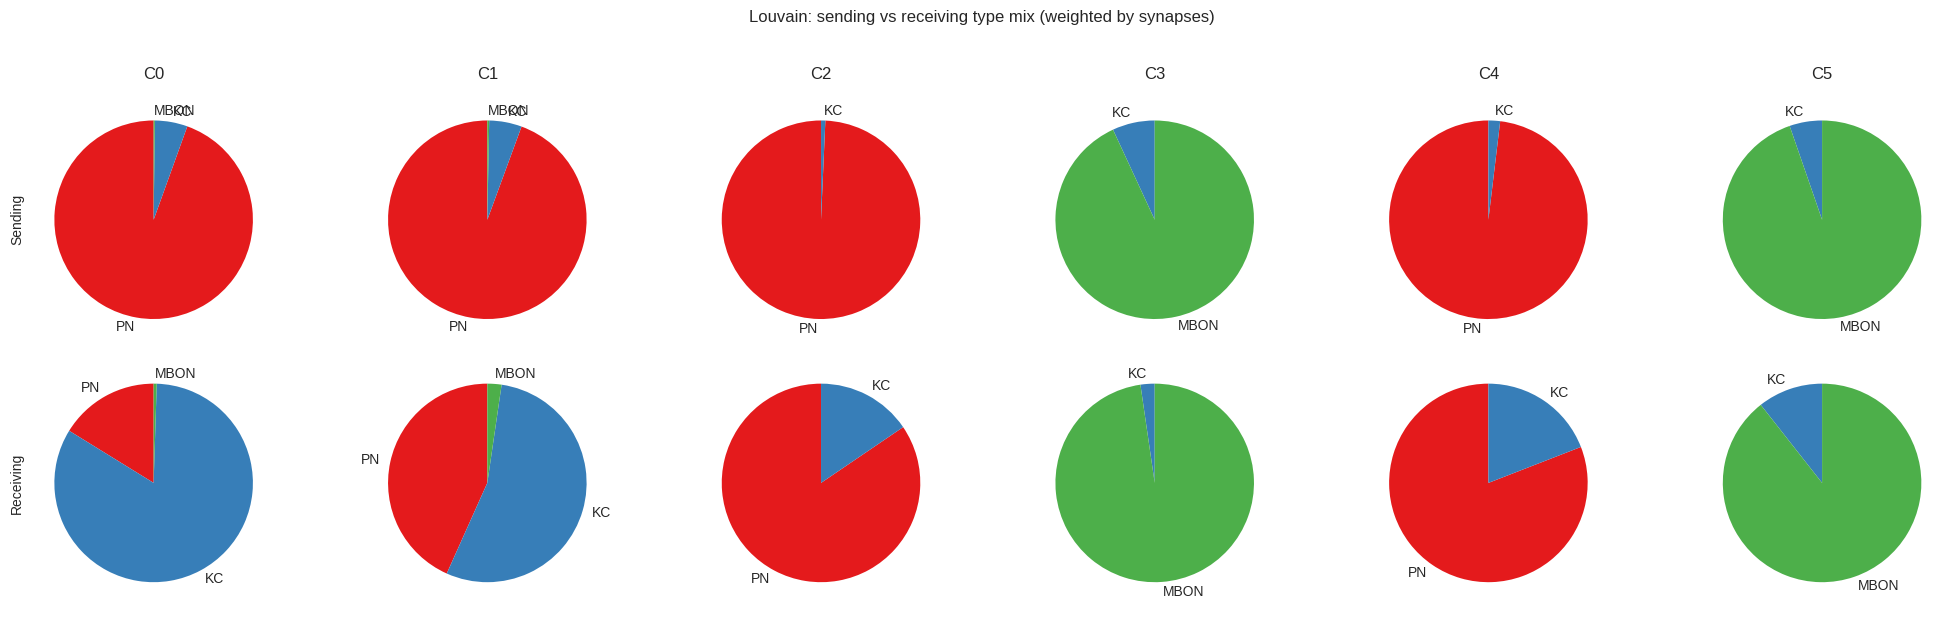

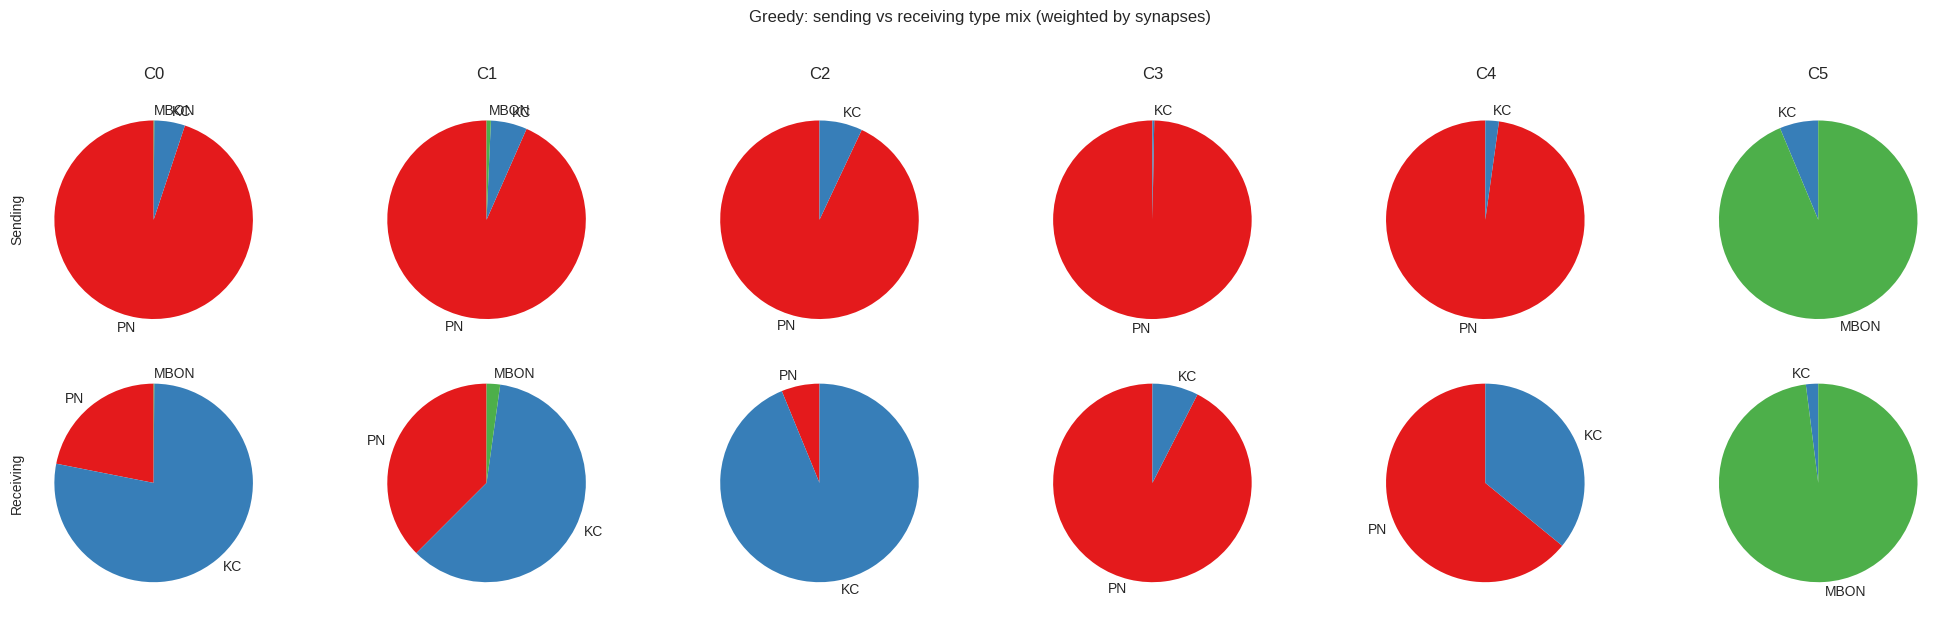

In [13]:

TOP_COMMUNITIES = 6

for name, info in method_info.items():
    comm_ids = select_top_communities(info["summary"], top_k=TOP_COMMUNITIES)
    send_pct, recv_pct = community_send_receive_mix(
        edges_grouped,
        info["node_comm"],
        labels,
        EDGE_WEIGHT_COL,
        type_order=TYPE_ORDER,
    )
    plot_send_receive_pies(
        send_pct,
        recv_pct,
        comm_ids,
        TYPE_ORDER,
        f"{name}: sending vs receiving type mix (weighted by synapses)",
    )


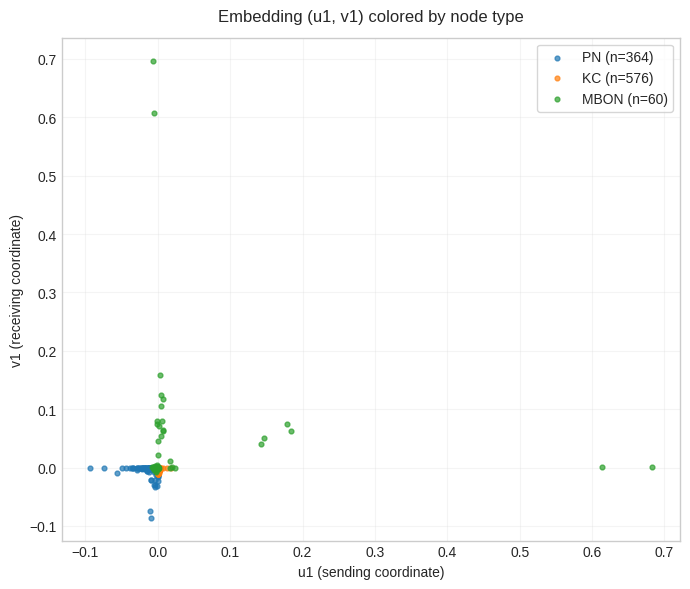

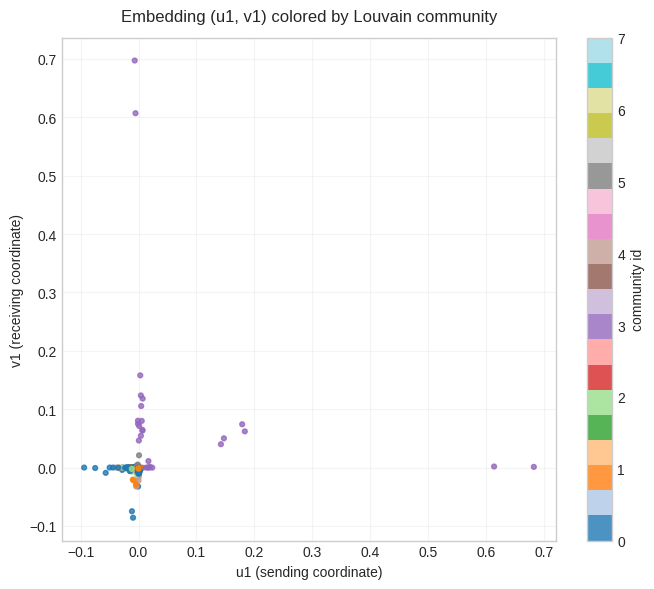

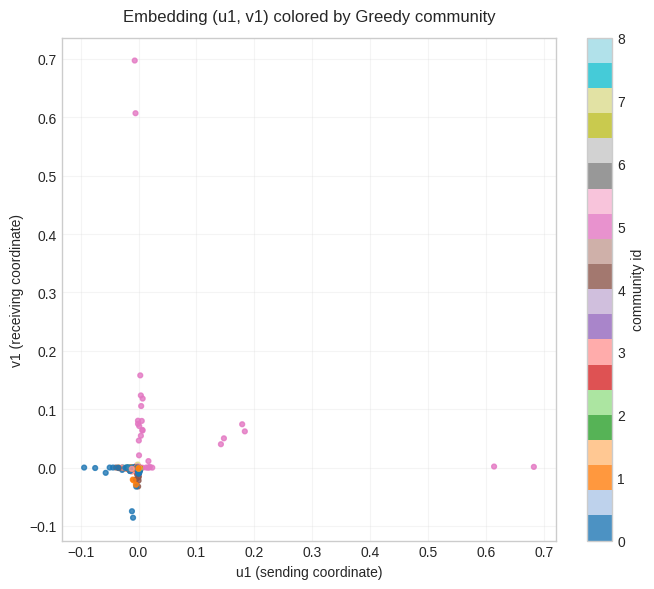

In [14]:
B = modularity_matrix(adj)
U, S, Vt = np.linalg.svd(B, full_matrices=False)
V = Vt.T

plot_embedding_by_type(U, V, labels, "Embedding (u1, v1) colored by node type")

for name, info in method_info.items():
    plot_embedding_by_comm(U, V, info["node_comm"], f"Embedding (u1, v1) colored by {name} community")


In [15]:
ami = adjusted_mutual_info_score(node_comm_louvain, node_comm_greedy)
print(f"Adjusted mutual information (Louvain vs Greedy): {ami:.4f}")


Adjusted mutual information (Louvain vs Greedy): 0.6339
